In [16]:
import os
import sys
import pandas as pd
import numpy as np
import missingno

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)

from utils import *

In [17]:
NUTS2 = 'CMacedonia'

In [18]:
base_path = f'../../data/{NUTS2}/results/'

In [19]:
file_list = os.listdir(base_path)
file_list.sort()
file_list

['GR_CMacedonia_Results_2010-2022.csv',
 'GR_CMacedonia_Results_2023-June-1st.csv',
 'GR_CMacedonia_Results_2023-June-2nd.csv',
 'GR_CMacedonia_Results_2023-May-1st.csv',
 'GR_CMacedonia_Results_2023-May-2nd.csv']

In [20]:
result_files = []

for file in file_list:
    data = pd.read_csv(f'{base_path}/{file}', encoding='utf-8')
    result_files.append(data)

In [21]:
concated = pd.concat(result_files, ignore_index=True, axis = 0)

In [34]:
concated[(concated['year'] == 2022) & (concated['month'] >= 5) & (concated['month'] <= 6)].case.sum()

0.0

In [7]:
concated.drop(columns=['case'], inplace = True)

<AxesSubplot:>

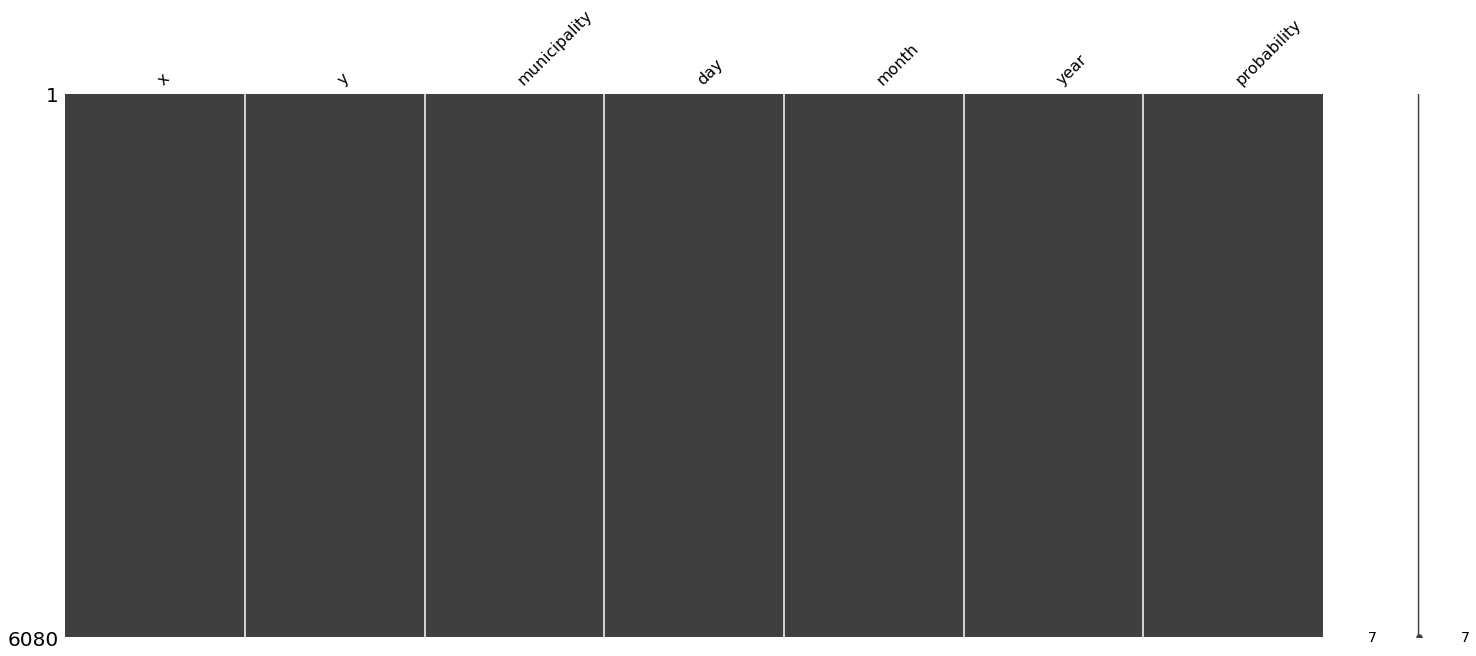

In [8]:
missingno.matrix(concated)

In [9]:
days = np.sort(concated.day.unique())
days

array([ 1, 16], dtype=int64)

In [10]:
months = np.sort(concated.month.unique())
months

array([ 5,  6,  7,  8,  9, 10, 11], dtype=int64)

In [11]:
years = np.sort(concated.year.unique())
years

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023], dtype=int64)

In [12]:
df_recent = df_multi_2 = concated[(concated['year'] >= 2019) & (concated['year'] <= 2023) & (concated['month'] >= 5) & (concated['month'] <= 6)].copy()
#df_recent = df_multi_2 = concated[(concated['year'] >= 2018) & (concated['year'] <= 2023)].copy()

In [13]:
df_recent.sort_values(by=['year', 'month', 'day'], ascending=True, inplace = True, ignore_index = True)

In [18]:
df_recent

,x,y,municipality,day,month,year,probability
0,22.89198,40.65603,αμπελοκηπων μενεμενης,1,6,2018,0.082947
1,22.15177,40.44520,βεροιας,1,6,2018,0.076004
2,21.99418,40.63248,ναουσας,1,6,2018,0.071577
3,23.23930,41.12421,ηρακλειας,1,6,2018,0.053698
4,22.33660,40.28529,κατερινης,1,6,2018,0.052825
...,...,...,...,...,...,...,...
527,22.47713,40.13156,διου ολυμπου,16,6,2023,0.123113
528,22.97547,40.65206,νεαπολης συκεων,16,6,2023,0.121655
529,23.40154,40.40778,πολυγυρου,16,6,2023,0.085626
530,23.82811,40.11026,σιθωνιας,16,6,2023,0.069223


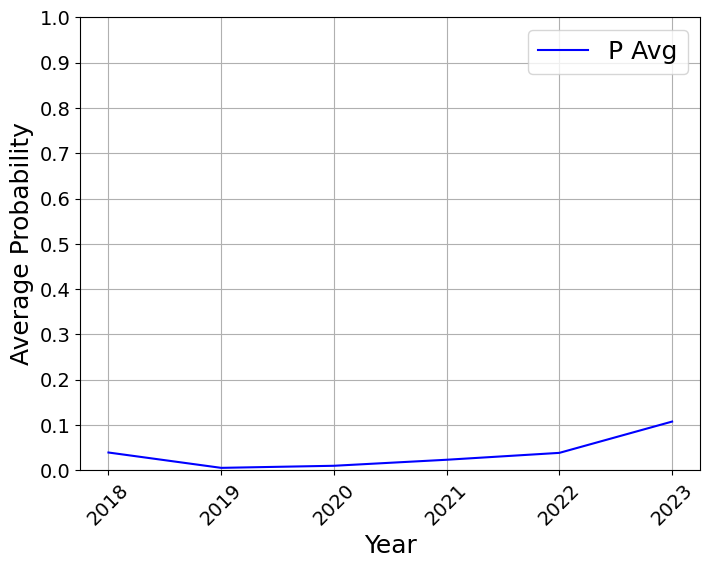

In [15]:
plot_trend_curve(df_recent, plot_cases=False)